# 04 — Statistical Analysis

Analysis of trip patterns, correlations, hypothesis testing, and revenue drivers.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import chi2_contingency

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:,.4f}".format)

## Project Paths

In [2]:
current_path = Path.cwd()

if current_path.name == "notebooks":
    project_root = current_path.parent
else:
    project_root = current_path

processed_data_dir = project_root / "data" / "processed"
reports_dir = project_root / "reports"
figures_dir = reports_dir / "figures"

processed_data_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

cleaned_trip_data_path = processed_data_dir / "cleaned_yellow_taxi_jan_2024.parquet"

print(f"Project root: {project_root}")
print(f"Cleaned dataset path exists: {cleaned_trip_data_path.exists()}")

Project root: /Users/ayushkumarsingh/Desktop/PROJECTS/Subject_assignments/NYCTaxiTripAnalytics
Cleaned dataset path exists: True


## Load Cleaned Dataset

In [3]:
taxi_trips = pd.read_parquet(cleaned_trip_data_path)

print(f"Cleaned taxi trips shape: {taxi_trips.shape[0]:,} rows and {taxi_trips.shape[1]:,} columns")
taxi_trips.head()

Cleaned taxi trips shape: 2,868,035 rows and 47 columns


,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,rate_code_id,store_and_fwd_flag,pickup_location_id,dropoff_location_id,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,trip_duration_minutes,passenger_count_clean,passenger_count_group,vendor_name,rate_code_label,payment_type_label,pickup_date,pickup_year,pickup_month,pickup_day,pickup_hour,pickup_day_name,pickup_day_of_week,is_weekend,revenue_per_mile,fare_per_minute,tip_percentage,distance_bucket,duration_bucket,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone,is_high_value_trip,is_long_distance_trip,is_long_duration_trip
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0000,1.7200,1.0000,N,186,79,2,17.7000,1.0000,0.5000,0.0000,0.0000,1.0000,22.7000,2.5000,0.0000,19.8000,1,Solo,VeriFone Inc.,Standard rate,Cash,2024-01-01,2024,1,1,0,Monday,0,False,13.1977,0.8939,0.0000,1-3 miles,10-20 min,Manhattan,Penn Station/Madison Sq West,Yellow Zone,Manhattan,East Village,Yellow Zone,False,False,False
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0000,1.8000,1.0000,N,140,236,1,10.0000,3.5000,0.5000,3.7500,0.0000,1.0000,18.7500,2.5000,0.0000,6.6000,1,Solo,Creative Mobile Technologies,Standard rate,Credit card,2024-01-01,2024,1,1,0,Monday,0,False,10.4167,1.5152,37.5000,1-3 miles,5-10 min,Manhattan,Lenox Hill East,Yellow Zone,Manhattan,Upper East Side North,Yellow Zone,False,False,False
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0000,4.7000,1.0000,N,236,79,1,23.3000,3.5000,0.5000,3.0000,0.0000,1.0000,31.3000,2.5000,0.0000,17.9167,1,Solo,Creative Mobile Technologies,Standard rate,Credit card,2024-01-01,2024,1,1,0,Monday,0,False,6.6596,1.3005,12.8755,3-5 miles,10-20 min,Manhattan,Upper East Side North,Yellow Zone,Manhattan,East Village,Yellow Zone,False,False,False
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0000,1.4000,1.0000,N,79,211,1,10.0000,3.5000,0.5000,2.0000,0.0000,1.0000,17.0000,2.5000,0.0000,8.3000,1,Solo,Creative Mobile Technologies,Standard rate,Credit card,2024-01-01,2024,1,1,0,Monday,0,False,12.1429,1.2048,20.0000,1-3 miles,5-10 min,Manhattan,East Village,Yellow Zone,Manhattan,SoHo,Yellow Zone,False,False,False
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0000,0.8000,1.0000,N,211,148,1,7.9000,3.5000,0.5000,3.2000,0.0000,1.0000,16.1000,2.5000,0.0000,6.1000,1,Solo,Creative Mobile Technologies,Standard rate,Credit card,2024-01-01,2024,1,1,0,Monday,0,False,20.1250,1.2951,40.5063,0-1 miles,5-10 min,Manhattan,SoHo,Yellow Zone,Manhattan,Lower East Side,Yellow Zone,False,False,False


## Prepare Statistical Analysis Dataset

In [4]:
analysis_columns = [
    "pickup_datetime",
    "pickup_hour",
    "pickup_day_name",
    "is_weekend",
    "trip_distance",
    "trip_duration_minutes",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "revenue_per_mile",
    "fare_per_minute",
    "tip_percentage",
    "passenger_count_clean",
    "payment_type_label",
    "pickup_borough",
    "dropoff_borough",
    "rate_code_label",
    "distance_bucket",
    "duration_bucket",
]

statistical_dataset = taxi_trips[analysis_columns].copy()

numeric_columns_for_cleaning = [
    "trip_distance",
    "trip_duration_minutes",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "revenue_per_mile",
    "fare_per_minute",
    "tip_percentage",
]

statistical_dataset[numeric_columns_for_cleaning] = statistical_dataset[numeric_columns_for_cleaning].replace(
    [np.inf, -np.inf],
    np.nan
)

statistical_dataset = statistical_dataset.dropna(subset=[
    "trip_distance",
    "trip_duration_minutes",
    "fare_amount",
    "total_amount",
    "payment_type_label",
    "pickup_borough",
    "distance_bucket",
])

print(f"Statistical dataset shape: {statistical_dataset.shape[0]:,} rows and {statistical_dataset.shape[1]:,} columns")

Statistical dataset shape: 2,868,035 rows and 19 columns


## Helper Functions

In [5]:
def interpret_p_value(p_value: float, alpha: float = 0.05) -> str:
    if p_value < alpha:
        return "Statistically significant"
    return "Not statistically significant"


def cohen_d(group_one: pd.Series, group_two: pd.Series) -> float:
    group_one = group_one.dropna()
    group_two = group_two.dropna()

    sample_size_one = len(group_one)
    sample_size_two = len(group_two)

    variance_one = group_one.var(ddof=1)
    variance_two = group_two.var(ddof=1)

    pooled_standard_deviation = np.sqrt(
        ((sample_size_one - 1) * variance_one + (sample_size_two - 1) * variance_two)
        / (sample_size_one + sample_size_two - 2)
    )

    if pooled_standard_deviation == 0:
        return 0

    return (group_one.mean() - group_two.mean()) / pooled_standard_deviation


def cramers_v(contingency_table: pd.DataFrame) -> float:
    chi2_statistic, _, _, _ = chi2_contingency(contingency_table)
    total_observations = contingency_table.to_numpy().sum()

    if total_observations == 0:
        return 0

    rows, columns = contingency_table.shape
    minimum_dimension = min(rows - 1, columns - 1)

    if minimum_dimension == 0:
        return 0

    return np.sqrt(chi2_statistic / (total_observations * minimum_dimension))


def save_dataframe(dataframe: pd.DataFrame, filename: str) -> None:
    output_path = processed_data_dir / filename
    dataframe.to_csv(output_path, index=False)
    print(f"Saved: {output_path}")

# 1. Correlation Analysis

In [6]:
correlation_columns = [
    "trip_distance",
    "trip_duration_minutes",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "revenue_per_mile",
    "fare_per_minute",
    "tip_percentage",
]

correlation_dataset = statistical_dataset[correlation_columns].dropna().copy()

# Use a sample for p-value calculations to keep runtime reasonable and reproducible.
correlation_sample_size = min(200_000, len(correlation_dataset))
correlation_sample = correlation_dataset.sample(n=correlation_sample_size, random_state=42)

pearson_correlation_matrix = correlation_sample.corr(method="pearson")
spearman_correlation_matrix = correlation_sample.corr(method="spearman")

pearson_correlation_matrix

,trip_distance,trip_duration_minutes,fare_amount,tip_amount,total_amount,revenue_per_mile,fare_per_minute,tip_percentage
trip_distance,1.0000,0.0226,0.0279,0.0187,0.0276,-0.0017,-0.0004,-0.0028
trip_duration_minutes,0.0226,1.0000,0.8135,0.4863,0.7884,-0.0558,-0.0309,-0.1826
fare_amount,0.0279,0.8135,1.0000,0.6033,0.9786,0.0651,0.0884,-0.1568
tip_amount,0.0187,0.4863,0.6033,1.0000,0.7265,0.0117,0.0372,0.4360
total_amount,0.0276,0.7884,0.9786,0.7265,1.0000,0.0511,0.0745,-0.0423
revenue_per_mile,-0.0017,-0.0558,0.0651,0.0117,0.0511,1.0000,0.4899,0.0004
fare_per_minute,-0.0004,-0.0309,0.0884,0.0372,0.0745,0.4899,1.0000,-0.0132
tip_percentage,-0.0028,-0.1826,-0.1568,0.4360,-0.0423,0.0004,-0.0132,1.0000


In [7]:
spearman_correlation_matrix

,trip_distance,trip_duration_minutes,fare_amount,tip_amount,total_amount,revenue_per_mile,fare_per_minute,tip_percentage
trip_distance,1.0000,0.8626,0.9290,0.4099,0.9016,-0.9248,-0.0277,-0.2742
trip_duration_minutes,0.8626,1.0000,0.9510,0.4128,0.9169,-0.6798,-0.3904,-0.2937
fare_amount,0.9290,0.9510,1.0000,0.4273,0.9636,-0.7718,-0.1775,-0.3076
tip_amount,0.4099,0.4128,0.4273,1.0000,0.5745,-0.1890,-0.0594,0.5812
total_amount,0.9016,0.9169,0.9636,0.5745,1.0000,-0.6945,-0.1549,-0.1074
revenue_per_mile,-0.9248,-0.6798,-0.7718,-0.1890,-0.6945,1.0000,-0.1322,0.3991
fare_per_minute,-0.0277,-0.3904,-0.1775,-0.0594,-0.1549,-0.1322,1.0000,0.0782
tip_percentage,-0.2742,-0.2937,-0.3076,0.5812,-0.1074,0.3991,0.0782,1.0000


In [8]:
correlation_test_results = []

target_column = "total_amount"

for column_name in correlation_columns:
    if column_name == target_column:
        continue

    test_data = correlation_sample[[column_name, target_column]].dropna()

    pearson_r, pearson_p_value = stats.pearsonr(test_data[column_name], test_data[target_column])
    spearman_r, spearman_p_value = stats.spearmanr(test_data[column_name], test_data[target_column])

    correlation_test_results.append({
        "variable": column_name,
        "pearson_correlation_with_total_amount": pearson_r,
        "pearson_p_value": pearson_p_value,
        "pearson_result": interpret_p_value(pearson_p_value),
        "spearman_correlation_with_total_amount": spearman_r,
        "spearman_p_value": spearman_p_value,
        "spearman_result": interpret_p_value(spearman_p_value),
    })

correlation_test_results_df = pd.DataFrame(correlation_test_results)
correlation_test_results_df = correlation_test_results_df.sort_values(
    by="spearman_correlation_with_total_amount",
    ascending=False
)

correlation_test_results_df

,variable,pearson_correlation_with_total_amount,pearson_p_value,pearson_result,spearman_correlation_with_total_amount,spearman_p_value,spearman_result
2,fare_amount,0.9786,0.0000,Statistically significant,0.9636,0.0000,Statistically significant
1,trip_duration_minutes,0.7884,0.0000,Statistically significant,0.9169,0.0000,Statistically significant
0,trip_distance,0.0276,0.0000,Statistically significant,0.9016,0.0000,Statistically significant
3,tip_amount,0.7265,0.0000,Statistically significant,0.5745,0.0000,Statistically significant
6,tip_percentage,-0.0423,0.0000,Statistically significant,-0.1074,0.0000,Statistically significant
5,fare_per_minute,0.0745,0.0000,Statistically significant,-0.1549,0.0000,Statistically significant
4,revenue_per_mile,0.0511,0.0000,Statistically significant,-0.6945,0.0000,Statistically significant


In [9]:
pearson_correlation_matrix.to_csv(processed_data_dir / "statistical_pearson_correlation_matrix.csv")
spearman_correlation_matrix.to_csv(processed_data_dir / "statistical_spearman_correlation_matrix.csv")
save_dataframe(correlation_test_results_df, "statistical_correlation_test_results.csv")

Saved: /Users/ayushkumarsingh/Desktop/PROJECTS/Subject_assignments/NYCTaxiTripAnalytics/data/processed/statistical_correlation_test_results.csv


# 2. Weekday vs Weekend Trip Behavior

In [10]:
weekday_weekend_metrics = [
    "trip_distance",
    "trip_duration_minutes",
    "total_amount",
    "revenue_per_mile",
]

weekday_weekend_test_results = []

# Sampling keeps the test practical and avoids huge-data p-values becoming the only story.
weekday_weekend_sample_size = min(300_000, len(statistical_dataset))
weekday_weekend_sample = statistical_dataset.sample(n=weekday_weekend_sample_size, random_state=42)

weekday_trips = weekday_weekend_sample[weekday_weekend_sample["is_weekend"] == False]
weekend_trips = weekday_weekend_sample[weekday_weekend_sample["is_weekend"] == True]

for metric_name in weekday_weekend_metrics:
    weekday_values = weekday_trips[metric_name].replace([np.inf, -np.inf], np.nan).dropna()
    weekend_values = weekend_trips[metric_name].replace([np.inf, -np.inf], np.nan).dropna()

    t_statistic, t_test_p_value = stats.ttest_ind(
        weekday_values,
        weekend_values,
        equal_var=False
    )

    mannwhitney_statistic, mannwhitney_p_value = stats.mannwhitneyu(
        weekday_values,
        weekend_values,
        alternative="two-sided"
    )

    effect_size = cohen_d(weekend_values, weekday_values)

    weekday_weekend_test_results.append({
        "metric": metric_name,
        "weekday_mean": weekday_values.mean(),
        "weekend_mean": weekend_values.mean(),
        "mean_difference_weekend_minus_weekday": weekend_values.mean() - weekday_values.mean(),
        "t_statistic": t_statistic,
        "t_test_p_value": t_test_p_value,
        "t_test_result": interpret_p_value(t_test_p_value),
        "mannwhitney_u_statistic": mannwhitney_statistic,
        "mannwhitney_p_value": mannwhitney_p_value,
        "mannwhitney_result": interpret_p_value(mannwhitney_p_value),
        "cohen_d_weekend_vs_weekday": effect_size,
    })

weekday_weekend_test_results_df = pd.DataFrame(weekday_weekend_test_results)
weekday_weekend_test_results_df

,metric,weekday_mean,weekend_mean,mean_difference_weekend_minus_weekday,t_statistic,t_test_p_value,t_test_result,mannwhitney_u_statistic,mannwhitney_p_value,mannwhitney_result,cohen_d_weekend_vs_weekday
0,trip_distance,3.6184,3.7504,0.1320,-0.2386,0.8114,Not statistically significant,"8,483,406,586.0000",0.0007,Statistically significant,0.0011
1,trip_duration_minutes,15.3956,13.7012,-1.6944,38.1032,0.0000,Statistically significant,"9,166,557,659.5000",0.0000,Statistically significant,-0.1441
2,total_amount,27.7746,26.1168,-1.6578,18.5934,0.0000,Statistically significant,"9,250,325,492.5000",0.0000,Statistically significant,-0.0765
3,revenue_per_mile,17.6059,16.4528,-1.1531,1.8997,0.0575,Not statistically significant,"9,301,010,592.0000",0.0000,Statistically significant,-0.0075


In [11]:
save_dataframe(weekday_weekend_test_results_df, "weekday_vs_weekend_statistical_tests.csv")

Saved: /Users/ayushkumarsingh/Desktop/PROJECTS/Subject_assignments/NYCTaxiTripAnalytics/data/processed/weekday_vs_weekend_statistical_tests.csv


In [12]:
weekend_summary_for_plot = (
    statistical_dataset
    .groupby("is_weekend")
    .agg(
        total_trips=("pickup_datetime", "count"),
        average_total_amount=("total_amount", "mean"),
        average_trip_distance=("trip_distance", "mean"),
        average_trip_duration=("trip_duration_minutes", "mean"),
        average_revenue_per_mile=("revenue_per_mile", "mean"),
    )
    .reset_index()
)

weekend_summary_for_plot["day_type"] = weekend_summary_for_plot["is_weekend"].map({
    False: "Weekday",
    True: "Weekend",
})

weekend_summary_for_plot

,is_weekend,total_trips,average_total_amount,average_trip_distance,average_trip_duration,average_revenue_per_mile,day_type
0,False,2134624,27.7593,3.7713,15.3921,17.5086,Weekday
1,True,733411,26.1139,3.6167,13.6889,17.4280,Weekend


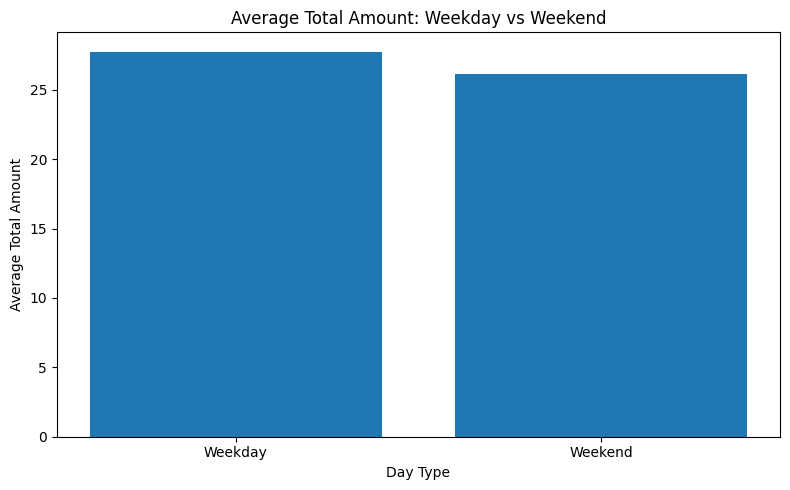

In [13]:
plt.figure(figsize=(8, 5))
plt.bar(weekend_summary_for_plot["day_type"], weekend_summary_for_plot["average_total_amount"])
plt.title("Average Total Amount: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Total Amount")
plt.tight_layout()
plt.savefig(figures_dir / "weekday_vs_weekend_average_total_amount.png", dpi=300)
plt.show()

# 3. Pickup Borough Group Comparison

In [14]:
borough_analysis_dataset = statistical_dataset[
    statistical_dataset["pickup_borough"].notna()
    & (statistical_dataset["pickup_borough"] != "Unknown")
    & statistical_dataset["total_amount"].notna()
].copy()

borough_counts = borough_analysis_dataset["pickup_borough"].value_counts()
valid_boroughs = borough_counts[borough_counts >= 1_000].index.tolist()

borough_analysis_dataset = borough_analysis_dataset[
    borough_analysis_dataset["pickup_borough"].isin(valid_boroughs)
].copy()

# Sample to keep tests practical and balanced.
borough_sample_size = min(300_000, len(borough_analysis_dataset))
borough_analysis_sample = borough_analysis_dataset.sample(n=borough_sample_size, random_state=42)

borough_groups = [
    group["total_amount"].dropna()
    for _, group in borough_analysis_sample.groupby("pickup_borough")
]

anova_statistic, anova_p_value = stats.f_oneway(*borough_groups)
kruskal_statistic, kruskal_p_value = stats.kruskal(*borough_groups)

borough_test_results = pd.DataFrame({
    "test_name": ["One-way ANOVA", "Kruskal-Wallis"],
    "test_statistic": [anova_statistic, kruskal_statistic],
    "p_value": [anova_p_value, kruskal_p_value],
    "result": [
        interpret_p_value(anova_p_value),
        interpret_p_value(kruskal_p_value),
    ],
})

borough_test_results

,test_name,test_statistic,p_value,result
0,One-way ANOVA,"74,907.7254",0.0000,Statistically significant
1,Kruskal-Wallis,"57,513.4906",0.0000,Statistically significant


In [15]:
pickup_borough_statistical_summary = (
    borough_analysis_dataset
    .groupby("pickup_borough")
    .agg(
        total_trips=("pickup_datetime", "count"),
        average_total_amount=("total_amount", "mean"),
        median_total_amount=("total_amount", "median"),
        std_total_amount=("total_amount", "std"),
        average_trip_distance=("trip_distance", "mean"),
        average_trip_duration=("trip_duration_minutes", "mean"),
        average_revenue_per_mile=("revenue_per_mile", "mean"),
    )
    .sort_values("average_total_amount", ascending=False)
    .reset_index()
)

pickup_borough_statistical_summary

,pickup_borough,total_trips,average_total_amount,median_total_amount,std_total_amount,average_trip_distance,average_trip_duration,average_revenue_per_mile
0,Queens,257603,72.2180,72.7800,30.9251,12.8148,32.3984,19.2825
1,Bronx,5742,35.4365,34.0000,16.9389,7.7331,38.1664,15.7615
2,Brooklyn,22254,33.1919,29.0000,19.6221,14.8153,31.6431,22.6189
3,Manhattan,2572024,22.7583,19.2500,13.9834,2.7171,13.0119,17.0235


In [16]:
save_dataframe(borough_test_results, "pickup_borough_group_comparison_tests.csv")
save_dataframe(pickup_borough_statistical_summary, "pickup_borough_statistical_summary.csv")

Saved: /Users/ayushkumarsingh/Desktop/PROJECTS/Subject_assignments/NYCTaxiTripAnalytics/data/processed/pickup_borough_group_comparison_tests.csv
Saved: /Users/ayushkumarsingh/Desktop/PROJECTS/Subject_assignments/NYCTaxiTripAnalytics/data/processed/pickup_borough_statistical_summary.csv


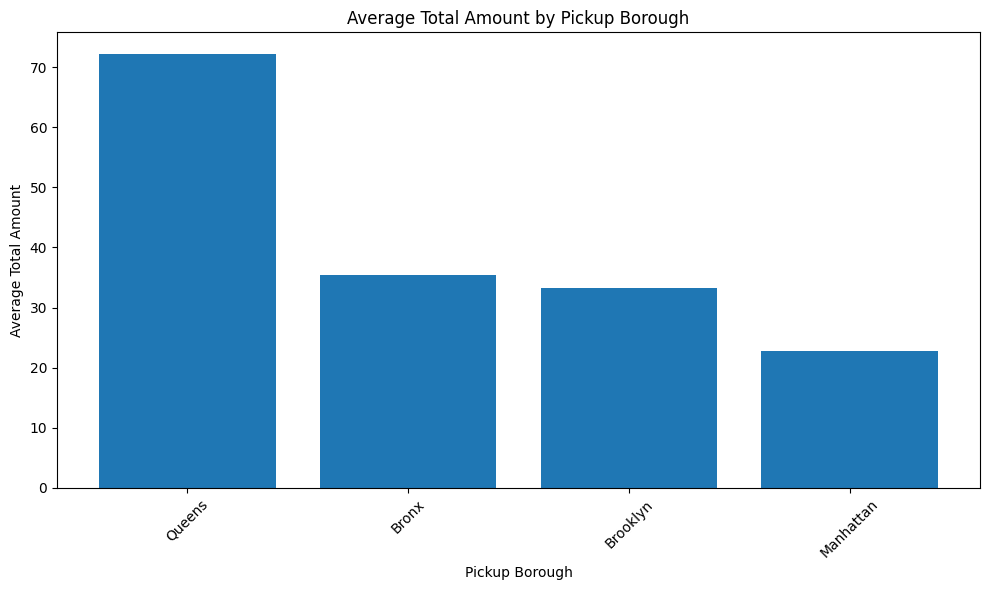

In [17]:
plt.figure(figsize=(10, 6))
plt.bar(
    pickup_borough_statistical_summary["pickup_borough"],
    pickup_borough_statistical_summary["average_total_amount"],
)
plt.title("Average Total Amount by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Average Total Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(figures_dir / "average_total_amount_by_pickup_borough.png", dpi=300)
plt.show()

# 4. Payment Type and Distance Bucket Relationship

In [18]:
payment_distance_dataset = statistical_dataset[
    statistical_dataset["payment_type_label"].isin(["Credit card", "Cash"])
    & statistical_dataset["distance_bucket"].notna()
].copy()

payment_distance_contingency_table = pd.crosstab(
    payment_distance_dataset["payment_type_label"],
    payment_distance_dataset["distance_bucket"]
)

payment_distance_contingency_table

distance_bucket,0-1 miles,1-3 miles,3-5 miles,5-10 miles,10-20 miles,20+ miles
payment_type_label,,,,,,
Cash,121242,191060,39373,34538,31062,5020
Credit card,555110,1143969,241602,176561,156919,22830


In [19]:
chi2_statistic, chi2_p_value, degrees_of_freedom, expected_frequencies = chi2_contingency(
    payment_distance_contingency_table
)

payment_distance_cramers_v = cramers_v(payment_distance_contingency_table)

payment_distance_test_results = pd.DataFrame({
    "test_name": ["Chi-square test of independence"],
    "chi2_statistic": [chi2_statistic],
    "degrees_of_freedom": [degrees_of_freedom],
    "p_value": [chi2_p_value],
    "result": [interpret_p_value(chi2_p_value)],
    "cramers_v": [payment_distance_cramers_v],
})

payment_distance_test_results

,test_name,chi2_statistic,degrees_of_freedom,p_value,result,cramers_v
0,Chi-square test of independence,"5,348.9767",5,0.0000,Statistically significant,0.0444


In [20]:
payment_distance_distribution = pd.crosstab(
    payment_distance_dataset["distance_bucket"],
    payment_distance_dataset["payment_type_label"],
    normalize="index"
) * 100

payment_distance_distribution = payment_distance_distribution.reset_index()

payment_distance_distribution

payment_type_label,distance_bucket,Cash,Credit card
0,0-1 miles,17.9259,82.0741
1,1-3 miles,14.3113,85.6887
2,3-5 miles,14.0130,85.9870
3,5-10 miles,16.3610,83.6390
4,10-20 miles,16.5240,83.4760
5,20+ miles,18.0251,81.9749


In [21]:
save_dataframe(payment_distance_test_results, "payment_distance_chi_square_test.csv")
save_dataframe(payment_distance_distribution, "payment_distance_distribution_percentages.csv")

Saved: /Users/ayushkumarsingh/Desktop/PROJECTS/Subject_assignments/NYCTaxiTripAnalytics/data/processed/payment_distance_chi_square_test.csv
Saved: /Users/ayushkumarsingh/Desktop/PROJECTS/Subject_assignments/NYCTaxiTripAnalytics/data/processed/payment_distance_distribution_percentages.csv


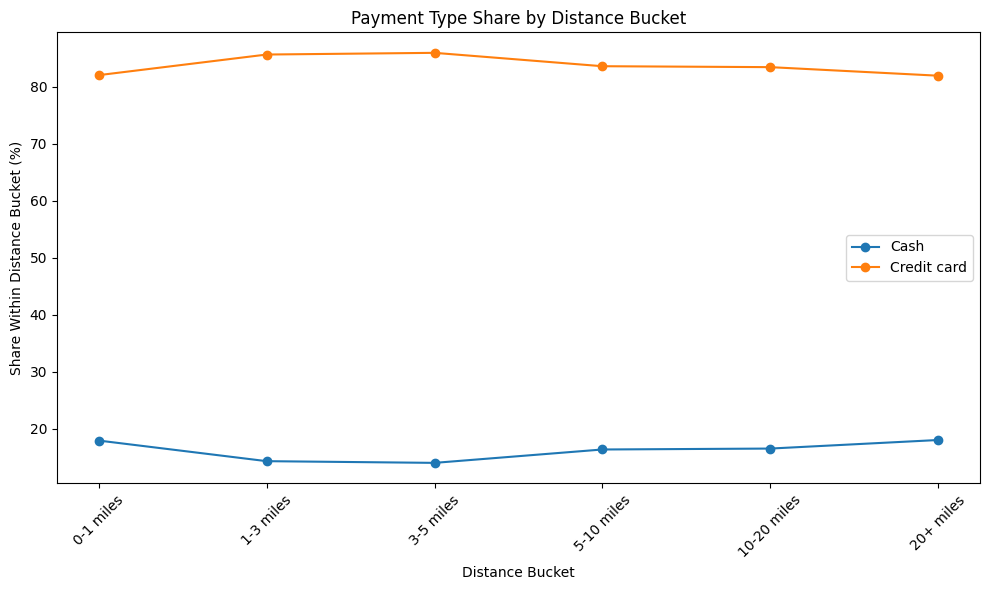

In [22]:
payment_distance_distribution_plot = payment_distance_distribution.set_index("distance_bucket")

plt.figure(figsize=(10, 6))

for payment_type in payment_distance_distribution_plot.columns:
    plt.plot(
        payment_distance_distribution_plot.index.astype(str),
        payment_distance_distribution_plot[payment_type],
        marker="o",
        label=payment_type,
    )

plt.title("Payment Type Share by Distance Bucket")
plt.xlabel("Distance Bucket")
plt.ylabel("Share Within Distance Bucket (%)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "payment_type_share_by_distance_bucket.png", dpi=300)
plt.show()

# 5. Tip Behavior Analysis

In [23]:
tip_analysis_dataset = statistical_dataset[
    statistical_dataset["payment_type_label"].isin(["Credit card", "Cash"])
].copy()

tip_analysis_sample_size = min(300_000, len(tip_analysis_dataset))
tip_analysis_sample = tip_analysis_dataset.sample(n=tip_analysis_sample_size, random_state=42)

credit_card_tips = tip_analysis_sample.loc[
    tip_analysis_sample["payment_type_label"] == "Credit card",
    "tip_percentage"
].replace([np.inf, -np.inf], np.nan).dropna()

cash_tips = tip_analysis_sample.loc[
    tip_analysis_sample["payment_type_label"] == "Cash",
    "tip_percentage"
].replace([np.inf, -np.inf], np.nan).dropna()

tip_t_statistic, tip_t_p_value = stats.ttest_ind(
    credit_card_tips,
    cash_tips,
    equal_var=False
)

tip_mannwhitney_statistic, tip_mannwhitney_p_value = stats.mannwhitneyu(
    credit_card_tips,
    cash_tips,
    alternative="two-sided"
)

tip_effect_size = cohen_d(credit_card_tips, cash_tips)

tip_test_results = pd.DataFrame({
    "comparison": ["Credit card vs Cash"],
    "credit_card_average_tip_percentage": [credit_card_tips.mean()],
    "cash_average_tip_percentage": [cash_tips.mean()],
    "mean_difference_credit_minus_cash": [credit_card_tips.mean() - cash_tips.mean()],
    "t_statistic": [tip_t_statistic],
    "t_test_p_value": [tip_t_p_value],
    "t_test_result": [interpret_p_value(tip_t_p_value)],
    "mannwhitney_u_statistic": [tip_mannwhitney_statistic],
    "mannwhitney_p_value": [tip_mannwhitney_p_value],
    "mannwhitney_result": [interpret_p_value(tip_mannwhitney_p_value)],
    "cohen_d_credit_vs_cash": [tip_effect_size],
    "interpretation_note": [
        "Cash tips may be under-recorded, so this result should be treated as recorded-tip behavior, not complete customer tipping behavior."
    ],
})

tip_test_results

,comparison,credit_card_average_tip_percentage,cash_average_tip_percentage,mean_difference_credit_minus_cash,t_statistic,t_test_p_value,t_test_result,mannwhitney_u_statistic,mannwhitney_p_value,mannwhitney_result,cohen_d_credit_vs_cash,interpretation_note
0,Credit card vs Cash,25.5105,0.0005,25.5100,852.2940,0.0000,Statistically significant,"11,501,046,356.5000",0.0000,Statistically significant,1.8413,"Cash tips may be under-recorded, so this resul..."


In [24]:
payment_tip_summary = (
    tip_analysis_dataset
    .groupby("payment_type_label")
    .agg(
        total_trips=("pickup_datetime", "count"),
        average_tip_amount=("tip_amount", "mean"),
        median_tip_amount=("tip_amount", "median"),
        average_tip_percentage=("tip_percentage", "mean"),
        median_tip_percentage=("tip_percentage", "median"),
        average_total_amount=("total_amount", "mean"),
    )
    .reset_index()
)

payment_tip_summary

,payment_type_label,total_trips,average_tip_amount,median_tip_amount,average_tip_percentage,median_tip_percentage,average_total_amount
0,Cash,422295,0.0001,0.0000,0.0010,0.0000,23.8320
1,Credit card,2296991,4.1558,3.1400,26.2805,26.2500,28.0722


In [25]:
save_dataframe(tip_test_results, "tip_behavior_statistical_test.csv")
save_dataframe(payment_tip_summary, "payment_tip_statistical_summary.csv")

Saved: /Users/ayushkumarsingh/Desktop/PROJECTS/Subject_assignments/NYCTaxiTripAnalytics/data/processed/tip_behavior_statistical_test.csv
Saved: /Users/ayushkumarsingh/Desktop/PROJECTS/Subject_assignments/NYCTaxiTripAnalytics/data/processed/payment_tip_statistical_summary.csv


# 6. Regression Analysis: Revenue Drivers

In [26]:
regression_columns = [
    "total_amount",
    "trip_distance",
    "trip_duration_minutes",
    "pickup_hour",
    "is_weekend",
    "passenger_count_clean",
    "pickup_borough",
    "payment_type_label",
    "rate_code_label",
]

regression_dataset = statistical_dataset[regression_columns].copy()

regression_dataset = regression_dataset.replace([np.inf, -np.inf], np.nan)
regression_dataset = regression_dataset.dropna()

regression_dataset = regression_dataset[
    (regression_dataset["total_amount"] >= 0)
    & (regression_dataset["trip_distance"] > 0)
    & (regression_dataset["trip_duration_minutes"] > 0)
].copy()

# Cap extreme values for modeling stability.
for column_name in ["total_amount", "trip_distance", "trip_duration_minutes"]:
    upper_limit = regression_dataset[column_name].quantile(0.99)
    regression_dataset = regression_dataset[regression_dataset[column_name] <= upper_limit].copy()

regression_sample_size = min(300_000, len(regression_dataset))
regression_sample = regression_dataset.sample(n=regression_sample_size, random_state=42)

print(f"Regression sample shape: {regression_sample.shape[0]:,} rows and {regression_sample.shape[1]:,} columns")
regression_sample.head()

Regression sample shape: 300,000 rows and 9 columns


,total_amount,trip_distance,trip_duration_minutes,pickup_hour,is_weekend,passenger_count_clean,pickup_borough,payment_type_label,rate_code_label
842351,16.8000,1.0500,8.9667,11,False,1,Manhattan,Credit card,Standard rate
1142801,12.2000,0.9800,5.0833,13,True,1,Manhattan,Credit card,Standard rate
2262481,23.1600,1.3400,12.4333,18,False,1,Manhattan,Credit card,Standard rate
572995,12.9000,0.9000,5.7000,8,False,1,Manhattan,Credit card,Standard rate
419709,24.8000,4.3000,19.8667,2,True,1,Manhattan,Cash,Standard rate


## Statsmodels OLS

In [27]:
regression_formula = """
total_amount ~ trip_distance
+ trip_duration_minutes
+ pickup_hour
+ is_weekend
+ passenger_count_clean
+ C(pickup_borough)
+ C(payment_type_label)
+ C(rate_code_label)
"""

ols_model = smf.ols(
    formula=regression_formula,
    data=regression_sample
).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:           total_amount   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.930
Method:                 Least Squares   F-statistic:                 1.980e+05
Date:                Tue, 28 Apr 2026   Prob (F-statistic):               0.00
Time:                        09:31:50   Log-Likelihood:            -8.7560e+05
No. Observations:              300000   AIC:                         1.751e+06
Df Residuals:                  299979   BIC:                         1.751e+06
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [28]:
ols_coefficients = pd.DataFrame({
    "term": ols_model.params.index,
    "coefficient": ols_model.params.values,
    "p_value": ols_model.pvalues.values,
    "confidence_interval_lower": ols_model.conf_int()[0].values,
    "confidence_interval_upper": ols_model.conf_int()[1].values,
})

ols_coefficients["result"] = ols_coefficients["p_value"].apply(interpret_p_value)

ols_coefficients = ols_coefficients.sort_values(
    by="coefficient",
    ascending=False
)

ols_coefficients.head(30)

,term,coefficient,p_value,confidence_interval_lower,confidence_interval_upper,result
13,C(rate_code_label)[T.Negotiated fare],24.0705,0.0000,23.6878,24.4533,Statistically significant
11,C(payment_type_label)[T.Unknown],16.0648,0.0000,15.8130,16.3167,Statistically significant
14,C(rate_code_label)[T.Newark],15.5728,0.0000,14.8607,16.2849,Statistically significant
6,C(pickup_borough)[T.Staten Island],13.1101,0.0035,4.3165,21.9037,Statistically significant
0,Intercept,12.2520,0.0000,11.7713,12.7327,Statistically significant
3,C(pickup_borough)[T.EWR],6.3161,0.0471,0.0800,12.5521,Statistically significant
5,C(pickup_borough)[T.Queens],5.5898,0.0000,5.1377,6.0420,Statistically significant
8,C(payment_type_label)[T.Credit card],4.3414,0.0000,4.2958,4.3870,Statistically significant
17,trip_distance,3.1290,0.0000,3.1182,3.1398,Statistically significant
9,C(payment_type_label)[T.Dispute],0.6667,0.0000,0.4816,0.8517,Statistically significant


In [29]:
save_dataframe(ols_coefficients, "ols_revenue_driver_coefficients.csv")

ols_model_summary = pd.DataFrame({
    "metric": [
        "r_squared",
        "adjusted_r_squared",
        "aic",
        "bic",
        "number_of_observations",
    ],
    "value": [
        ols_model.rsquared,
        ols_model.rsquared_adj,
        ols_model.aic,
        ols_model.bic,
        int(ols_model.nobs),
    ],
})

save_dataframe(ols_model_summary, "ols_revenue_driver_model_summary.csv")
ols_model_summary

Saved: /Users/ayushkumarsingh/Desktop/PROJECTS/Subject_assignments/NYCTaxiTripAnalytics/data/processed/ols_revenue_driver_coefficients.csv
Saved: /Users/ayushkumarsingh/Desktop/PROJECTS/Subject_assignments/NYCTaxiTripAnalytics/data/processed/ols_revenue_driver_model_summary.csv


,metric,value
0,r_squared,0.9296
1,adjusted_r_squared,0.9296
2,aic,"1,751,245.6125"
3,bic,"1,751,468.4548"
4,number_of_observations,"300,000.0000"


## Scikit-learn Prediction

In [30]:
machine_learning_dataset = regression_sample.copy()

machine_learning_features = [
    "trip_distance",
    "trip_duration_minutes",
    "pickup_hour",
    "is_weekend",
    "passenger_count_clean",
    "pickup_borough",
    "payment_type_label",
    "rate_code_label",
]

target_column = "total_amount"

X = machine_learning_dataset[machine_learning_features]
y = machine_learning_dataset[target_column]

X_encoded = pd.get_dummies(
    X,
    columns=["pickup_borough", "payment_type_label", "rate_code_label"],
    drop_first=True,
    dtype=int
)

X_encoded["is_weekend"] = X_encoded["is_weekend"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

linear_regression_model = LinearRegression()
linear_regression_model.fit(X_train, y_train)

y_predicted = linear_regression_model.predict(X_test)

regression_mae = mean_absolute_error(y_test, y_predicted)
regression_rmse = np.sqrt(mean_squared_error(y_test, y_predicted))
regression_r2 = r2_score(y_test, y_predicted)

sklearn_regression_performance = pd.DataFrame({
    "metric": [
        "Mean Absolute Error",
        "Root Mean Squared Error",
        "R-squared",
        "Training Rows",
        "Testing Rows",
    ],
    "value": [
        regression_mae,
        regression_rmse,
        regression_r2,
        len(X_train),
        len(X_test),
    ],
})

sklearn_regression_performance

,metric,value
0,Mean Absolute Error,2.3550
1,Root Mean Squared Error,4.4922
2,R-squared,0.9289
3,Training Rows,"240,000.0000"
4,Testing Rows,"60,000.0000"


In [31]:
save_dataframe(sklearn_regression_performance, "sklearn_revenue_model_performance.csv")

Saved: /Users/ayushkumarsingh/Desktop/PROJECTS/Subject_assignments/NYCTaxiTripAnalytics/data/processed/sklearn_revenue_model_performance.csv
